# 16 — Lyapunov MPC: Session 1 平坦スモーク（RAL 2025）

**目的:** 同じ flat シナリオで **nominal** と **Lyapunov 安定性制約** を比較。

> **Lyapunov トラック（Notebook 16–19）** — Session 1–4 と **同シナリオ** の並行追加。  
> 技術: Elobaid et al. **RAL 2025** — **Lyapunov 安定性制約**付き centroidal NMPC（`mpc_params.type: lyapunov`）。  
> preset: `session0X_*_lyapunov.yaml` · 結果: `assets/lyapunov_lab_results.json`


## Nominal vs Lyapunov（同シナリオ · 同 acados 系）

| | **Nominal（01–05）** | **Lyapunov（16–19）** |
|---|---------------------|------------------------|
| **論文** | centroidal NMPC baseline | **RAL 2025 安定性保証付き reformulation** |
| **求解** | acados 勾配法 | acados + **Lyapunov 制約** |
| **GRF** | 最適化変数 | 同（GRF 12D + 摩擦円錐 + 安定性） |
| **足場 opt** | Session 3–4 で ON | **ON（gradient 系）** |
| **preset** | `session0X_*` | `session0X_*_lyapunov` |


### 参照: Nominal Session 1 GIF

Markdown の `![](../assets/...)` だけでは IDE 内で見えないことがあります。下のセルで **GIF を直接表示** します。

--- s01_flat ---
  scene: flat
  final_x_m: 1.267
  gif_playback_s: 10.0


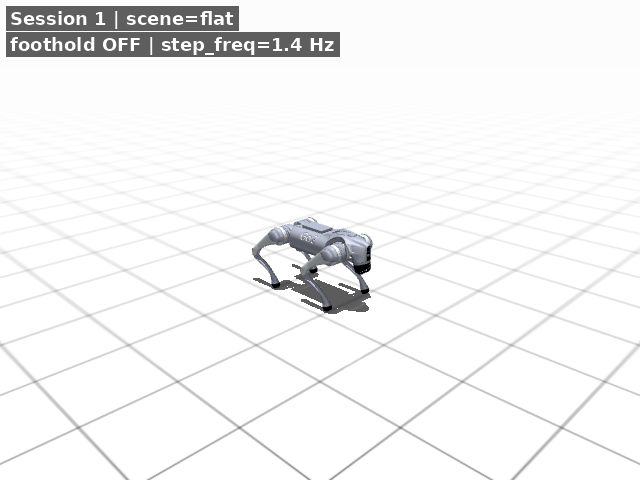

In [1]:
from pathlib import Path
import sys
import json
from IPython.display import Image, display

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break

def show_demo_gifs(tags):
    for tag in tags:
        gif = ROOT / f"docs/pympc_2day/assets/demo_{tag}.gif"
        meta_path = ROOT / f"docs/pympc_2day/assets/demo_{tag}.meta.json"
        print(f"--- {tag} ---")
        if meta_path.is_file():
            m = json.loads(meta_path.read_text())
            for k in ("scene", "final_x_m", "final_dist_m", "gif_playback_s", "falls"):
                if m.get(k) is not None:
                    print(f"  {k}: {m[k]}")
        if gif.is_file():
            display(Image(filename=str(gif)))
        else:
            print("  MISSING:", gif)

show_demo_gifs(["s01_flat"])


In [2]:
import sys
from pathlib import Path

# mpc_dog ルートを sys.path に追加
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pympc_lab import (
    TUNING_GUIDE,
    apply_preset,
    compare_runs,
    load_param_study,
    load_preset_yaml,
    plot_friction_cone,
    run_flat_sim,
    run_speed_terrain_sim,
    run_speed_terrain_sim_resilient,
)

from tuning_labs import (
    TUNING_LABS,
    list_labs,
    run_lab,
    run_lab_pair,
    plot_speed_trial_journey,
    plot_param_study_mu,
    load_cached_lab_results,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
print(f"repo: {ROOT}")

from lyapunov_labs import load_results, compare_table, LYAPUNOV_LABS


repo: /home/takuya/work/mpc_dog


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session01_flat_smoke_lyapunov/config.py.bak.20260818T231752Z
applied: session01_flat_smoke_lyapunov -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: First run: acados codegen for lyapunov model (~1–5 min). Compare nominal vs lyapunov in notebook 16.


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


External functions generated in 202.523 ms.


Templated solver code generated in 1249.990 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_1d26474f.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_1d26474f.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

...

Templated solver code generated in 1234.265 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_1d26474f.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_1d26474f.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_1d26474f.o acados_solver_ocp_centro

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_1d26474f.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


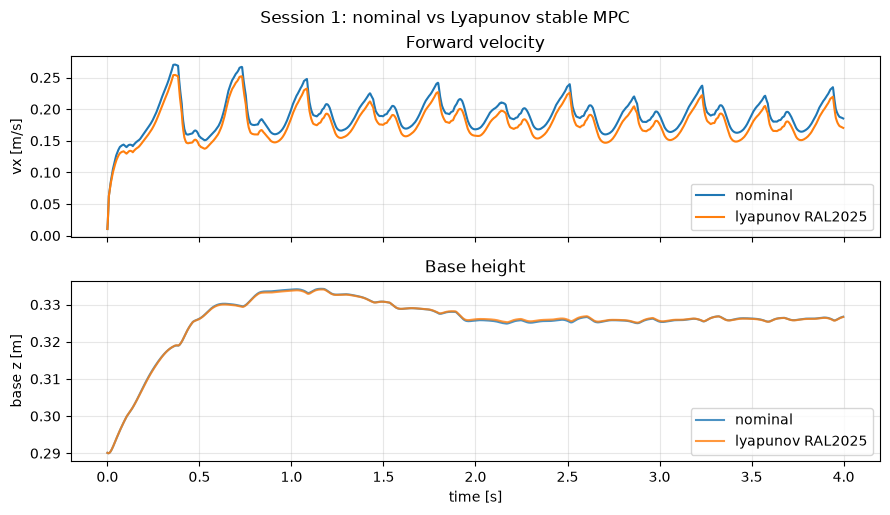

In [3]:
apply_preset("session01_flat_smoke_lyapunov")
lya = run_flat_sim(seconds=4.0)
apply_preset("session01_flat_smoke")
nom = run_flat_sim(seconds=4.0)
fig = compare_runs([("nominal", nom), ("lyapunov RAL2025", lya)])
plt.suptitle("Session 1: nominal vs Lyapunov stable MPC", y=1.02)
plt.show()


In [4]:
import pandas as pd
data = load_results()
if "lya_s1_flat" in data:
    display(pd.DataFrame([data["lya_s1_flat"]["result"]]))


,mean_vx,std_vx,min_z,max_roll_deg,steps,terminated
0,0.223304,0.031056,0.289993,0.954461,2000,False
